In [1]:
from libraries import*
from simulation_B_spin_modified import  wX, Ispin, w0, delta_ppm, eta, CQ_M, Qeta, alpha, beta, gamma, QPAS, Siso_ppm, Siso, QXG, CsaQXG, AcsQXG
from functions import fourier3, fourier5, fourier6, Rabc, Quad, ChemShift, AntiShift
from scipy.interpolate import make_interp_spline
import sympy as sym
from sympy import *
B0 = 14.1 #magnetic field used
w0 = 192.55 #input for 11B 
# print(w0)
wX = w0*10**6 #actual freq in Hz
Ispin = 3/2 #spin of 11B
#(https://pages.nyu.edu/jerschow/NMRmap/NMRmap_deployed.html)

Welcome to JupyROOT 6.26/06
iminuit version: 2.17.0


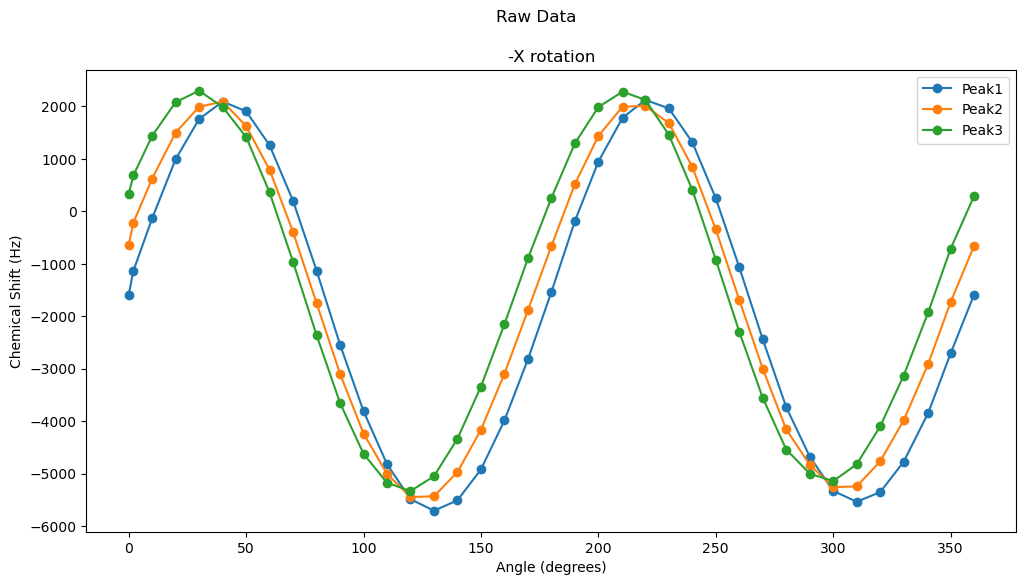

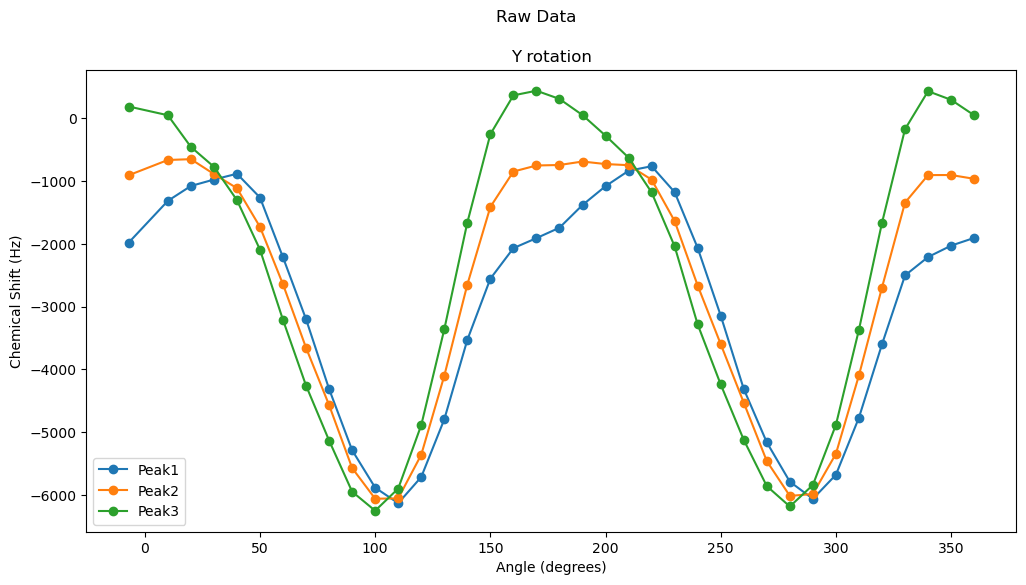

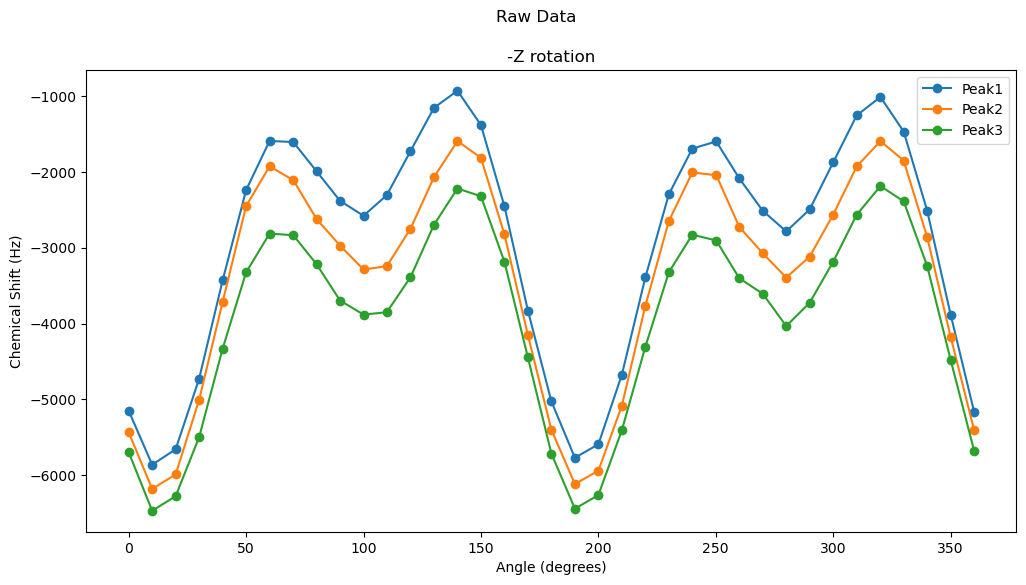

In [12]:
titles = ['-X rotation', 'Y rotation', '-Z rotation']
df = [0]*3

    
df[0] = pd.read_excel('//home/shiva/WMU/PhD/Scripts/phd_project/Python/NMR/Data_exp/B_Rotation_Plot.xlsx', sheet_name='(-)8HQ_X_Rot', skiprows=[1])
df[1] = pd.read_excel('//home/shiva/WMU/PhD/Scripts/phd_project/Python/NMR/Data_exp/B_Rotation_Plot.xlsx', sheet_name='(-)8HQ_Y_Rot', skiprows=[1])
df[2] = pd.read_excel('//home/shiva/WMU/PhD/Scripts/phd_project/Python/NMR/Data_exp/B_Rotation_Plot.xlsx', sheet_name='(-)8HQ_Z_Rot', skiprows=[1])
for i in range(3):

    df[i].Cluster1Peak0 = df[i].Cluster1Peak0*w0
    df[i].Cluster1Peak1 = df[i].Cluster1Peak1*w0
    df[i].Cluster1Peak2 = df[i].Cluster1Peak2*w0

    # print(df[i].Cluster1Peak1)
    plt.figure(figsize=(12, 6))


    plt.plot(df[i].Angle, df[i].Cluster1Peak0, label = 'Peak1', marker='o')
    plt.plot(df[i].Angle, df[i].Cluster1Peak1, label = 'Peak2', marker='o')
    plt.plot(df[i].Angle, df[i].Cluster1Peak2, label = 'Peak3', marker='o')
    plt.suptitle('Raw Data')
    plt.xlabel('Angle (degrees)')
    plt.ylabel('Chemical Shift (Hz)')
    plt.title(titles[i])
    plt.legend()
    plt.show()

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1.756e+07 (chi2/ndof = 532222.0)│              Nfcn = 151              │
│ EDM = 4.22e-17 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │        No Parameters at limit        │
├──────────────────────────────────┼──────────────────────────────────────┤
│ Below EDM threshold (goal x 10)  │           Below call limit           │
├───────────────┬──────────────────┼───────────┬─────────────┬────────────┤
│  Covariance   │     Hesse ok     │ Accurate  │  Pos. def.  │ Not forced │
└───────────────┴──────────────────┴───────────┴─────────────┴────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬─

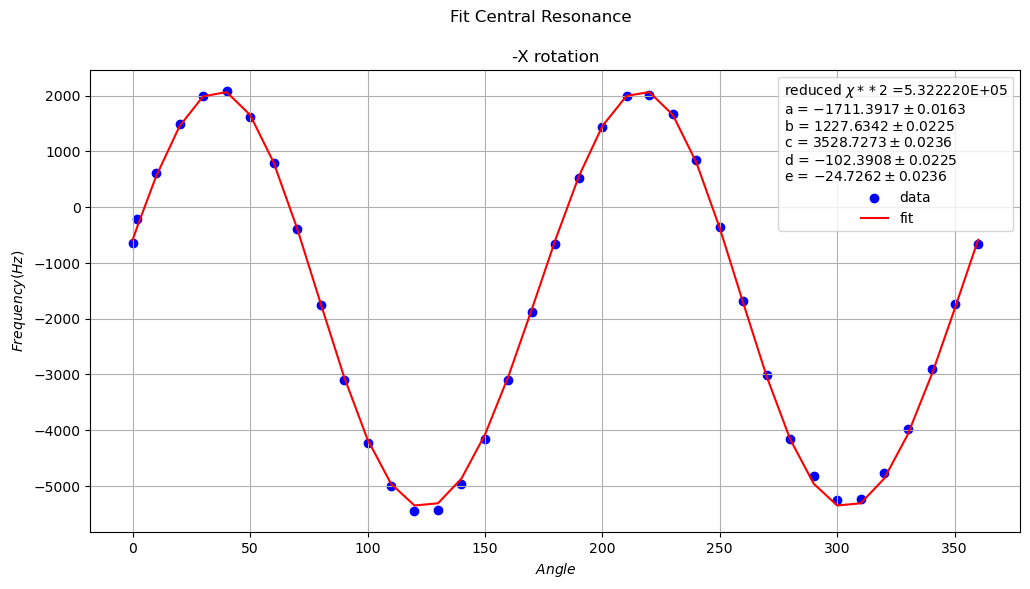

a = -1711.3917405144725
b = 1227.6342191424676
c = 3528.7272816468644
d = -102.39079523353186
e = -24.726206186999043
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 8.816e+07 (chi2/ndof = 2755082.6)│              Nfcn = 129              │
│ EDM = 1.88e-15 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │        No Parameters at limit        │
├──────────────────────────────────┼──────────────────────────────────────┤
│ Below EDM threshold (goal x 10)  │           Below call limit           │
├───────────────┬──────────────────┼───────────┬─────────────┬────────────┤
│  Covariance   │     Hesse ok     │ Accurate  │  Pos. def.  │ Not forced │
└───────────────┴──────────────────┴────

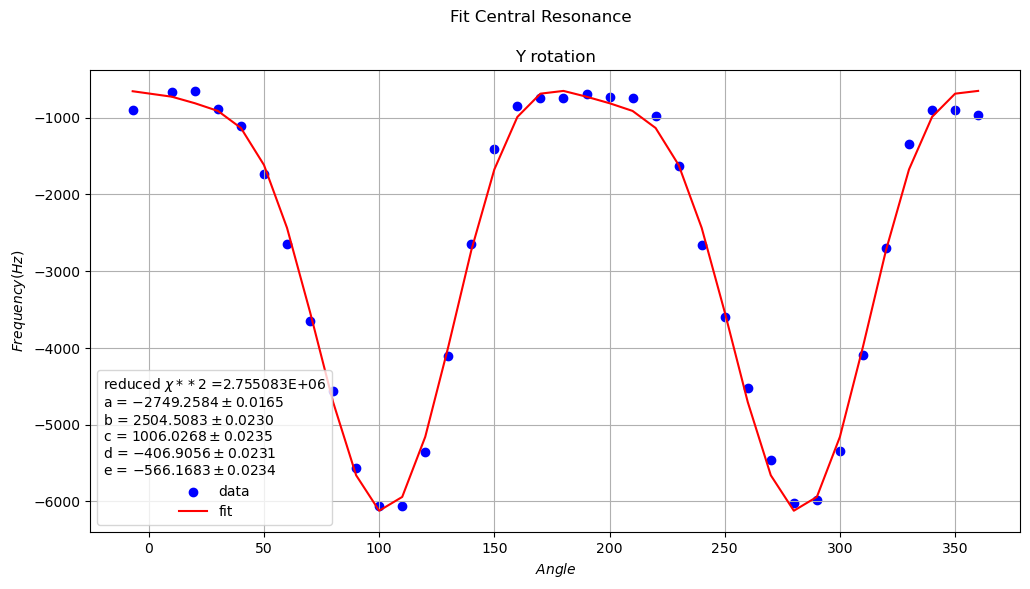

a = -2749.258376608953
b = 2504.5083087974936
c = 1006.0267825093252
d = -406.90571560631145
e = -566.1682695097219
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 2.166e+07 (chi2/ndof = 676757.4)│              Nfcn = 139              │
│ EDM = 4.36e-17 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │        No Parameters at limit        │
├──────────────────────────────────┼──────────────────────────────────────┤
│ Below EDM threshold (goal x 10)  │           Below call limit           │
├───────────────┬──────────────────┼───────────┬─────────────┬────────────┤
│  Covariance   │     Hesse ok     │ Accurate  │  Pos. def.  │ Not forced │
└───────────────┴──────────────────┴───────

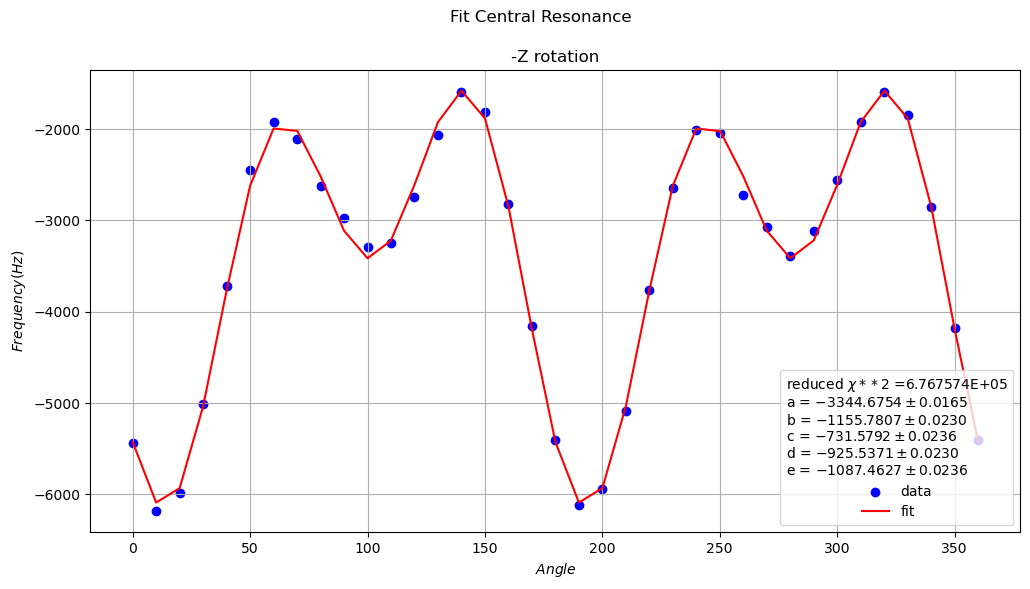

a = -3344.6754051030207
b = -1155.7807401848006
c = -731.5791893329126
d = -925.537095775468
e = -1087.4626639385958


In [7]:
m_Q = [0]*3

for i in range(3):
    least_squares = LeastSquares(df[i].Angle, df[i].Cluster1Peak1, 0.1,fourier5)
    
    m_Q[i] = Minuit(least_squares, a = 1, b = 1, c= 1, d = 0, e = 1).migrad()
    # m[i] = m[i].scan(ncall = 50)

    # m[i].migrad()  # finds minimum of least_squares function
    m_Q[i].hesse()   # accurately computes uncertainties
    
    fit_info = [
        f"reduced $\\chi**2$ ={(m_Q[i].fval / (len(df[i].Angle) - m_Q[i].nfit)):5E}"
    ]
    # print(fit_info)
    
    for p, v, e in zip(m_Q[i].parameters, m_Q[i].values, m_Q[i].errors):
        fit_info.append(f"{p} = ${v:.4f} \\pm {e:.4f}$")

    print(m_Q[i].migrad())
    # plt.imshow(corr_mat, cmap='coolwarm')
    
    # draw data and fitted line
    plt.figure(figsize=(12, 6))
    plt.scatter(df[i].Angle, df[i].Cluster1Peak1, label="data", color = 'blue')
    plt.plot(df[i].Angle, fourier5(df[i].Angle, *m_Q[i].values), label="fit", color = 'red')
    plt.xlabel(r'$Angle$')
    plt.ylabel(r'$Frequency (Hz)$')
    # plt.title(titles[i] +'\n'r'$Fitting\ of\ H^1_{CSA} = A + B(cos2\theta )+ C(sin2\theta)$')
    plt.suptitle('Fit Central Resonance')
    plt.title(titles[i])
    plt.legend(title="\n".join(fit_info))
    plt.grid()
    plt.show()
    
    for key, value in zip(m_Q[i].parameters, m_Q[i].values):
        print(f"{key} = {value}")

In [10]:
a = [0]*3; 
b = [0]*3; 
c = [0]*3; 
d = [0]*3
e = [0]*3

par_Q = [a, b, c, d, e]
for i in range(0,3):
    for k in range(len(par_Q)):
        par_Q[k][i] = m_Q[i].values[k]

fact = (16*wX)/(9*(4*Ispin*(Ispin + 1) - 3))


#X rotation
AyymAzz = np.sqrt(4*fact*(d[0] + np.sqrt(d[0]**2 + e[0]**2)))
Ayz_Q = np.sqrt(fact*(-d[0] + np.sqrt(d[0]**2 + e[0]**2)))

#Y rotation
AxxmAzz = np.sqrt(4*fact*(d[1] + np.sqrt(d[1]**2 + e[1]**2)))
Axz_Q = np.sqrt(fact*(-d[1] + np.sqrt(d[1]**2 + e[1]**2)))

#Z rotation
AxxmAyy = np.sqrt(4*fact*(d[2] + np.sqrt(d[2]**2 + e[2]**2)))
Axy_Q = np.sqrt(fact*(-d[2] + np.sqrt(d[2]**2 + e[2]**2)))

Axx1  = (AxxmAzz + AxxmAyy)/3
Ayy1 = Axx1 - AxxmAyy
Azz1 = Axx1 - AxxmAzz

Ayy2 = (AyymAzz - AxxmAyy)/3
Axx2 = Ayy2 + AxxmAyy
Azz2 = Ayy2 - AyymAzz

Azz3 = (AxxmAzz + AyymAzz)/3
Axx3 = Azz3 + AxxmAzz
Ayy3 = Azz3 + AyymAzz

Axx_Q = (Axx1 + Axx2 + Axx3)/3
Ayy_Q = (Ayy1 + Ayy2 + Ayy3)/3
Azz_Q = (Azz1 + Azz2 + Azz3)/3

# print(Axx1, Axx2, Axx3, Ayy1, Ayy2, Ayy3, Azz1, Azz2, Azz3)
QXG_f = np.zeros((3, 3))                                #Fit tensor
QXG_f[0,0] = Axx_Q; QXG_f[0,1] = Axy_Q; QXG_f[0,2] = Axz_Q;
QXG_f[1,0] = Axy_Q; QXG_f[1,1] = Ayy_Q; QXG_f[1,2] = Ayz_Q;
QXG_f[2,0] = Axz_Q; QXG_f[2,1] = Ayz_Q; QXG_f[2,2] = Azz_Q;


print('Calculated Quad Tensor:\n',QXG_f)

Calculated Quad Tensor:
 [[185001.40663546 259107.93957387 177471.88682756]
 [259107.93957387 -29187.77778312  76977.55059175]
 [177471.88682756  76977.55059175 -22259.08983605]]


In [11]:
q = (3 - 4*Ispin*(Ispin + 1))/(16*wX)

#X rotation
AzzpAyy = ((8*Axx_Q*(Ayy_Q + Azz_Q - Axx_Q) + 16*(Axy_Q**2 + Axz_Q**2) + 5*(Ayy_Q**2 + Azz_Q**2) + 28*(Ayz_Q**2 - 18*Ayy_Q*Azz_Q))*(q/8) - a[0])*(2/wX)
AzzmAyy = ((2*Axx_Q*(Ayy_Q - Azz_Q) - 12*((Axy_Q)**2 - Axz_Q**2) - Ayy_Q**2 + Azz_Q**2)*(q/2) - b[0])*(2/wX)
Ayz_csa = (-(-2*Axx_Q*Ayz_Q + 12*Axy_Q*Axz_Q + Ayz_Q*(Ayy_Q + Azz_Q))*q - c[0])*(1/wX)

#Y rotation.
AzzpAxx = ((8*Ayy_Q*(Axx_Q + Azz_Q - Ayy_Q) + 16*(Axy_Q**2 + Ayz_Q**2) + 5*(Axx_Q**2 + Azz_Q**2) + 28*(Axz_Q**2 - 18*Axx_Q*Azz_Q))*(q/8) - a[1])*(2/wX)
AzzmAxx = ((2*Ayy_Q*(Axx_Q - Azz_Q) - 12*((Axy_Q)**2 - Ayz_Q**2) - Axx_Q**2 + Azz_Q**2)*(q/2) - b[1])*(2/wX)
Axz_csa = (-(-2*Ayy_Q*Axz_Q + 12*Axy_Q*Ayz_Q + Axz_Q*(Axx_Q + Azz_Q))*q - c[1])*(1/wX)

#Z rotation
AyypAxx = ((8*Azz_Q*(Axx_Q + Ayy_Q - Azz_Q) + 16*(Axz_Q**2 + Ayz_Q**2) + 5*(Axx_Q**2 + Ayy_Q**2) + 28*(Axy_Q**2 - 18*Axx_Q*Ayy_Q))*(q/8) - a[2])*(2/wX)
AyymAxx = ((2*Azz_Q*(Axx_Q - Ayy_Q) - 12*((Axz_Q)**2 - Ayz_Q**2) - Axx_Q**2 + Ayy_Q**2)*q/2 + b[2])*(2/wX)
Axy_csa = (-(-2*Azz_Q*Axy_Q + 12*Axz_Q*Ayz_Q + Axy_Q*(Axx_Q + Ayy_Q))*q + c[2])*(1/wX)


Azz1_csa = (AzzpAyy + AzzmAyy)/2
Ayy1_csa = (AzzpAyy - AzzmAyy)/2

Azz2_csa = (AzzpAxx + AzzmAxx)/2
Axx1_csa = (AzzpAxx - AzzmAxx)/2

Ayy2_csa = (AyypAxx + AyymAxx)/2
Axx2_csa = (AyypAxx + AyymAxx)/2

# print(Axx1_csa, Axx2_csa, Ayy1_csa, Ayy2_csa, Azz1_csa, Azz2_csa)
# print(AzzpAyy)

Axx_csa = np.mean([Axx1_csa, Axx2_csa])
Ayy_csa = np.mean([Ayy1_csa, Ayy2_csa])
Azz_csa = np.mean([Azz1_csa, Azz2_csa])

CsaQXG_f = np.zeros((3, 3))                                #Fit tensor
CsaQXG_f[0,0] = Axx_csa; CsaQXG_f[0,1] = Axy_csa; CsaQXG_f[0,2] = Axz_csa;
CsaQXG_f[1,0] = Axy_csa; CsaQXG_f[1,1] = Ayy_csa; CsaQXG_f[1,2] = Ayz_csa;
CsaQXG_f[2,0] = Axz_csa; CsaQXG_f[2,1] = Ayz_csa; CsaQXG_f[2,2] = Azz_csa;


print('Calculated CSA Tensor:\n',CsaQXG_f)

Calculated CSA Tensor:
 [[ 5.01289028e-06  5.66877253e-07  4.10800859e-07]
 [ 5.66877253e-07  4.79366769e-06 -7.81995300e-06]
 [ 4.10800859e-07 -7.81995300e-06  1.27900646e-06]]
